<a href="https://colab.research.google.com/github/giyuubin/group-project/blob/main/Malware_Feature_Selection_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. 데이터 불러오기
print("데이터를 불러오는 중입니다...")
df = pd.read_csv('top_1000_pe_imports.csv')

# 데이터에 존재하는 빈칸(결측치) 행을 모두 제거합니다.
print("결측치(빈칸) 데이터를 정제하는 중입니다...")
df = df.dropna()

# 2. 문제(X)와 정답(y) 분리
X = df.drop(columns=['hash', 'malware'])
y = df['malware']

# 3. 랜덤 포레스트 모델 학습 (특징 중요도 추출 목적)
print("특징 중요도를 평가하고 있습니다. 잠시만 기다려주세요...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 4. 특징 중요도(Feature Importance) 추출 및 정렬
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. 상위 30개 핵심 API 추출
top_30_features = feature_importance_df.head(30)['Feature'].tolist()
print("\n[상위 30개 핵심 API]")
for i, api in enumerate(top_30_features, 1):
    print(f"{i}. {api}")

# 6. 최적화된 데이터프레임 생성 및 저장
optimized_columns = top_30_features + ['malware']
optimized_df = df[optimized_columns]

optimized_df.to_csv('optimized_data.csv', index=False)
print("\n✅ 가벼워진 데이터가 'optimized_data.csv' 파일로 성공적으로 저장되었습니다!")

데이터를 불러오는 중입니다...
결측치(빈칸) 데이터를 정제하는 중입니다...
특징 중요도를 평가하고 있습니다. 잠시만 기다려주세요...

[상위 30개 핵심 API]
1. _cexit
2. _exit
3. exit
4. __setusermatherr
5. __set_app_type
6. __p__commode
7. _initterm
8. malloc
9. __p__fmode
10. free
11. SetUnhandledExceptionFilter
12. InterlockedExchange
13. __getmainargs
14. _onexit
15. UnhandledExceptionFilter
16. QueryPerformanceCounter
17. ExitProcess
18. VirtualFree
19. InterlockedCompareExchange
20. _XcptFilter
21. VirtualAlloc
22. _controlfp
23. SearchPathW
24. HeapSetInformation
25. GetSystemTimeAsFileTime
26. VirtualProtect
27. GetModuleHandleA
28. GetDC
29. TerminateProcess
30. RegCloseKey

✅ 가벼워진 데이터가 'optimized_data.csv' 파일로 성공적으로 저장되었습니다!



특징 중요도 그래프를 생성하는 중입니다...


/tmp/ipykernel_12827/3106552802.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(



✅ 상위 30개 API 중요도 그래프가 'feature_importance_top30.png' 파일로 성공적으로 저장되었습니다!


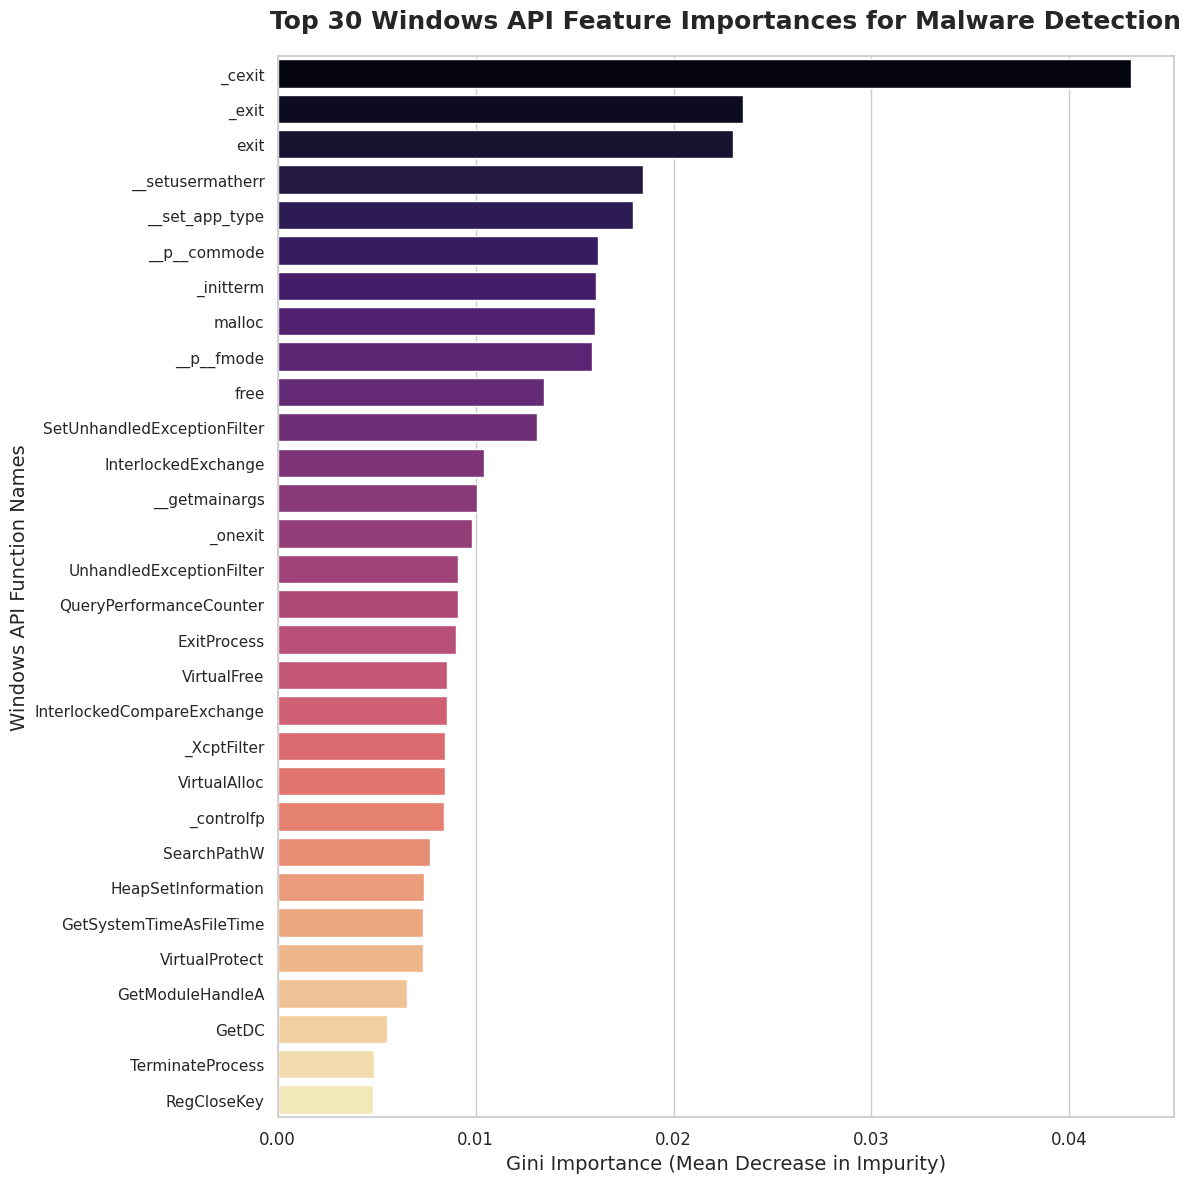

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7. 특징 중요도 시각화 및 이미지 저장
print("\n특징 중요도 그래프를 생성하는 중입니다...")

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")

# 그래프 사이즈 설정
plt.figure(figsize=(12, 12))

# 상위 30개 데이터로 가로 막대그래프 생성
chart = sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(30),
    palette='magma'
)

# 그래프 제목 및 라벨 설정
plt.title('Top 30 Windows API Feature Importances for Malware Detection', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Gini Importance (Mean Decrease in Impurity)', fontsize=14)
plt.ylabel('Windows API Function Names', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

plt.tight_layout()

# 고화질 이미지 파일로 자동 저장
plot_filename = 'feature_importance_top30.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')

print(f"\n✅ 상위 30개 API 중요도 그래프가 '{plot_filename}' 파일로 성공적으로 저장되었습니다!")

# 그래프 화면 출력
plt.show()